**[CHANGE]**: Analyze per-category behaviour after 2021 trend break

This notebook assumes that `HF_flood_daily_series.py` script and `test_EDA.py` scripts have been run.

***

__author__ = "Macarena Merida Floriano, mmef" <br>
__maintainer__ = "Macarena Merida Floriano, mmef"<br>
__email__ = "mmef@gmv.com"

***

In [ ]:
from datetime import datetime
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy import stats

In [ ]:
PARQUET_PATH = "../data/eo_pool/eo_pool.parquet"
df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(df)} facilities from parquet.")
for col in ['series_binary', 'series_pct_flood_pixels', 'series_distance_m']:
    df[col] = df[col].apply(json.loads)
df['dates'] = df['dates'].apply(
    lambda x: [datetime.strptime(d, '%Y-%m-%d') for d in json.loads(x)]
)

Loaded 7126 facilities from parquet.


In [ ]:
print(f"Number of unique facilities: {len(df['hf_id'].unique())}")

505

In [ ]:
zones_df = "../data/EDA/hf_areas_persistence_variability.csv"
df_zones = pd.read_csv(zones_df)
print(f"Loaded {len(df_zones)} zones from CSV.")
df_zones.head()

Loaded 509 zones from CSV.


,hf_id,lat,lon,row,col,zona,zona_nombre,persistence,cv,color
0,abiemnom phcc,9.398740,28.823400,276,275,2,Chronic,0.845156,0.488055,#0072c6
1,awarpiny phcu,9.473620,28.888280,186,353,2,Chronic,1.010833,0.533724,#0072c6
2,manajoga phcu,9.392128,28.811239,283,260,2,Chronic,1.877708,0.764371,#0072c6
3,panyang phcu,9.409190,28.912590,263,382,1,Safe,0.132014,0.039362,#efeff1
4,awal phcu,9.435215,28.619653,232,31,3,Unstable,2.908974,2.088133,#a3c7e3


In [ ]:
df_zones_unique = df_zones[['hf_id', 'zona_name']].drop_duplicates(subset='hf_id')
print(f"Number of unique facilities in zones data: {len(df_zones_unique)}")

505

In [ ]:
df_mod = df.merge(df_zones_unique[['hf_id', 'zona_name']], on='hf_id', how='inner')

In [ ]:
# Check df_mod structure
df_ab = df_mod[df_mod["hf_id"] == "abiemnom phcc"]
df_ab.head(14)

,hf_county,hf_payam,hf_id,hf_type,latitude,longitude,year,n_days,buffer_pixels,buffer_meters,total_pixels_buffer,dates,series_binary,series_pct_flood_pixels,series_distance_m,series_no_data_count,total_flooded_days,zona_nombre
0,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2012,337,40,3600.0,1600,"[2012-01-24 00:00:00, 2012-01-25 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,Chronic
1,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2013,363,40,3600.0,1600,"[2013-01-01 00:00:00, 2013-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",45,Chronic
2,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2014,365,40,3600.0,1600,"[2014-01-01 00:00:00, 2014-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15,Chronic
3,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2015,365,40,3600.0,1600,"[2015-01-01 00:00:00, 2015-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,Chronic
4,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2016,344,40,3600.0,1600,"[2016-01-23 00:00:00, 2016-01-24 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,Chronic
5,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2017,365,40,3600.0,1600,"[2017-01-01 00:00:00, 2017-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,Chronic
6,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2018,365,40,3600.0,1600,"[2018-01-01 00:00:00, 2018-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",54,Chronic
7,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2019,365,40,3600.0,1600,"[2019-01-01 00:00:00, 2019-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",125,Chronic
8,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2020,366,40,3600.0,1600,"[2020-01-01 00:00:00, 2020-01-02 00:00:00, 202...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,Chronic
9,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2021,306,40,3600.0,1600,"[2021-01-01 00:00:00, 2021-01-02 00:00:00, 202...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",9,Chronic


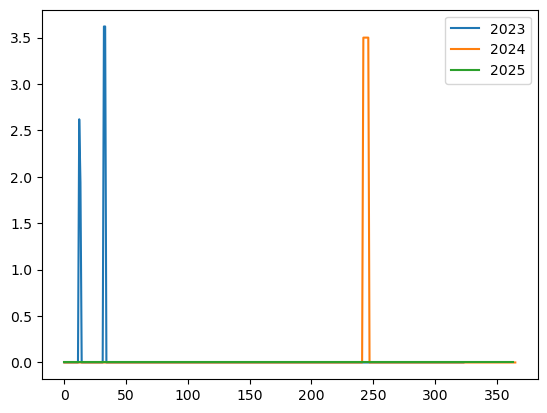

In [ ]:
# Check a facility flooding according to years available for SWOT data
ab_s_2023 = df_ab["series_pct_flood_pixels"].iloc[-3]
ab_s_2024 = df_ab["series_pct_flood_pixels"].iloc[-2]
ab_s_2025 = df_ab["series_pct_flood_pixels"].iloc[-1]
plt.plot(ab_s_2023)
plt.plot(ab_s_2024)
plt.plot(ab_s_2025)
plt.legend(["2023", "2024", "2025"])
plt.show()

In [ ]:
df_mod["zona_name"] = df_mod["zona_name"].str.upper()

### Check facilities behaviour pre and post 2021 per category
#### SAFE facilities
***

In [ ]:
BREAKPOINT = 2021

In [ ]:
safe_fac = df_mod[df_mod["zona_name"] == "SAFE"].copy()
print("Number of SAFE facilities: ", len(safe_fac))

3752

In [ ]:
# =========================================
# 1. AGGREGATED METRICS PER FACILITY X YEAR
# =========================================

def compute_annual_metrics(df):
    records = []
    for _, row in df.iterrows():
        binary = np.array(row['series_binary'])
        pct    = np.array(row['series_pct_flood_pixels'])
        
        n_days        = len(binary)
        flood_days    = int(binary.sum())
        flood_freq    = flood_days / n_days if n_days > 0 else 0
        mean_pct      = pct[binary == 1].mean() if flood_days > 0 else 0
        
        # Wet spell lengths
        spells = []
        count  = 0
        for v in binary:
            if v == 1:
                count += 1
            elif count > 0:
                spells.append(count)
                count = 0
        if count > 0:
            spells.append(count)
        
        max_spell  = max(spells) if spells else 0
        mean_spell = np.mean(spells) if spells else 0
        n_spells   = len(spells)
        
        records.append({
            'hf_id'      : row['hf_id'],
            'year'       : row['year'],
            'period'     : 'post' if row['year'] > BREAKPOINT else 'pre',
            'flood_days' : flood_days,
            'flood_freq' : flood_freq,
            'mean_pct'   : mean_pct,
            'max_spell'  : max_spell,
            'mean_spell' : mean_spell,
            'n_spells'   : n_spells,
        })
    return pd.DataFrame(records)


In [ ]:
# ============================================
# 2. STATISTICAL TEST PRE vs POST PER FACILITY
# ============================================

def test_pre_post(df_metrics):
    results = []
    for fid, g in df_metrics.groupby('hf_id'):
        pre  = g[g['period'] == 'pre' ]['flood_freq'].values
        post = g[g['period'] == 'post']['flood_freq'].values
        
        if len(pre) < 2 or len(post) < 2:
            continue
        
        mean_pre  = pre.mean()
        mean_post = post.mean()
        delta     = mean_post - mean_pre
        
        # Mann-Whitney (it does not assume normality, robust for short series)
        stat, pval = stats.mannwhitneyu(pre, post, alternative='two-sided')
        
        results.append({
            'hf_id'    : fid,
            'mean_pre' : mean_pre,
            'mean_post': mean_post,
            'delta'    : delta,
            'pval'     : pval,
            'significant': pval < 0.05,
        })
    
    return pd.DataFrame(results).sort_values('delta', ascending=False)

In [ ]:
# ==========================
# 3. CLASSIFICATION POST-HOC
# ==========================

def classify_safe_facilities(df_tests, freq_threshold=0.10):
    """
    Clasifica cada facility SAFE en:
      - SAFE_CONFIRMED  : sin cambio significativo, frecuencia post baja
      - SAFE_EMERGED    : frecuencia post alta aunque no significativo
      - SAFE_CHANGED    : cambio estadísticamente significativo
    """
    def classify(row):
        if row['significant']:
            return 'SAFE_CHANGED'
        elif row['mean_post'] >= freq_threshold:
            return 'SAFE_EMERGED'
        else:
            return 'SAFE_CONFIRMED'
    
    df_tests['reclassification'] = df_tests.apply(classify, axis=1)
    return df_tests

In [ ]:
# ================
# 4. VISUALIZATION
# ================

def plot_safe_analysis(df_metrics, df_tests, top_n_facilities=20):
    
    fig = plt.figure(figsize=(20, 24))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
    
    # ── Period palette ───────────────────────────────────────────────────
    CPRE  = '#2166ac'
    CPOST = '#d6604d'
    
    # ── 1. Flood frequency distribution pre vs post (all facilities) ─
    ax1 = fig.add_subplot(gs[0, 0])
    pre_all  = df_metrics[df_metrics['period'] == 'pre' ]['flood_freq']
    post_all = df_metrics[df_metrics['period'] == 'post']['flood_freq']
    bins = np.linspace(0, 1, 30)
    ax1.hist(pre_all,  bins=bins, alpha=0.6, color=CPRE,  label=f'Pre-{BREAKPOINT}',  density=True)
    ax1.hist(post_all, bins=bins, alpha=0.6, color=CPOST, label=f'Post-{BREAKPOINT}', density=True)
    ax1.set_xlabel('Flood frequency (annual)')
    ax1.set_ylabel('Density')
    ax1.set_title('Flood frequency distribution\n(all SAFE facilities)')
    ax1.legend(); ax1.grid(alpha=0.3)
    
    # ── 2. Delta (post - pre) per facility, ordered ─────────────────────
    ax2 = fig.add_subplot(gs[0, 1:])
    top = df_tests.head(top_n_facilities)
    colors = ['#d6604d' if s else '#92c5de' for s in top['significant']]
    ax2.barh(range(len(top)), top['delta'], color=colors, alpha=0.8)
    ax2.axvline(0, color='black', lw=1)
    ax2.set_yticks(range(len(top)))
    ax2.set_yticklabels(top['hf_id'], fontsize=7)
    ax2.set_xlabel('Δ flood frequency (post − pre)')
    ax2.set_title(f'Top-{top_n_facilities} facilities by Δ frequency\n'
                  f'(red = statistically significant, p<0.05)')
    ax2.grid(alpha=0.3, axis='x')
    
    # ── 3. Scatter mean_pre vs mean_post ─────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    cmap = {'SAFE_CONFIRMED': '#4dac26', 
            'SAFE_EMERGED'  : '#f1a340', 
            'SAFE_CHANGED'  : '#d6604d'}
    for cls, grp in df_tests.groupby('reclassification'):
        ax3.scatter(grp['mean_pre'], grp['mean_post'], 
                    label=cls, color=cmap[cls], alpha=0.7, s=40)
    lim = max(df_tests['mean_pre'].max(), df_tests['mean_post'].max()) * 1.05
    ax3.plot([0, lim], [0, lim], 'k--', lw=1, label='1:1')
    ax3.axhline(0.10, color='gray', ls=':', lw=1, label='Threshold 0.10')
    ax3.set_xlabel(f'Mean freq pre-{BREAKPOINT}')
    ax3.set_ylabel(f'Mean freq post-{BREAKPOINT}')
    ax3.set_title('Pre vs post flood frequency\nper SAFE facility')
    ax3.legend(fontsize=7); ax3.grid(alpha=0.3)
    
    # ── 4. p-value distribution ───────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(df_tests['pval'], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax4.axvline(0.05, color='red', lw=1.5, ls='--', label='p=0.05')
    ax4.set_xlabel('Mann-Whitney p-value')
    ax4.set_ylabel('Count')
    ax4.set_title('Distribution of p-values\n(pre vs post test per facility)')
    ax4.legend(); ax4.grid(alpha=0.3)
    
    # ── 5. Counting per reclassification ─────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    counts = df_tests['reclassification'].value_counts()
    bars   = ax5.bar(counts.index, counts.values, 
                     color=[cmap[c] for c in counts.index], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Number of facilities')
    ax5.set_title('Reclassification summary')
    ax5.grid(alpha=0.3, axis='y')
    
    # ── 6. Time series: annual mean across all SAFE facilities ─────────────────
    ax6 = fig.add_subplot(gs[2, :])
    annual_mean = (
        df_metrics.groupby('year')['flood_freq']
        .agg(['mean', 'std', lambda x: x.quantile(0.05), lambda x: x.quantile(0.95)])
    )
    annual_mean.columns = ['mean', 'std', 'q05', 'q95']
    
    years = annual_mean.index
    ax6.fill_between(years, annual_mean['q05'], annual_mean['q95'],
                     alpha=0.2, color='steelblue', label='5–95% across facilities')
    ax6.plot(years, annual_mean['mean'], color='steelblue', lw=2, marker='o',
             markersize=5, label='Mean across SAFE facilities')
    ax6.axvline(BREAKPOINT + 0.5, color='red', ls='--', lw=1.5,
                label=f'Breakpoint {BREAKPOINT}')
    
    # Color background pre/post
    ax6.axvspan(years.min(), BREAKPOINT + 0.5, alpha=0.05, color=CPRE)
    ax6.axvspan(BREAKPOINT + 0.5, years.max(), alpha=0.05, color=CPOST)
    
    ax6.set_xlabel('Year')
    ax6.set_ylabel('Mean flood frequency')
    ax6.set_title('Annual mean flood frequency across all SAFE facilities\n'
                  '(shading = 5–95% percentile range across facilities)')
    ax6.legend(); ax6.grid(alpha=0.3)
    ax6.set_xticks(years)
    
    fig.suptitle('SAFE facilities — Pre vs Post breakpoint analysis',
                 fontsize=14, fontweight='bold', y=1.01)
    
    return fig

In [ ]:
# ==========================
# 5. NUMERICAL SUMMARY
# ==========================

def print_summary(df_tests):
    print("\n" + "="*60)
    print("SAFE FACILITIES — RECLASSIFICATION SUMMARY")
    print("="*60)
    
    counts = df_tests['reclassification'].value_counts()
    total  = len(df_tests)
    for cls, n in counts.items():
        print(f"  {cls:<20}: {n:>4}  ({100*n/total:.1f}%)")
    
    print("\nFacilities to RECLASSIFY (SAFE_CHANGED + SAFE_EMERGED):")
    reclassify = df_tests[df_tests['reclassification'] != 'SAFE_CONFIRMED']
    print(reclassify[['hf_id','mean_pre','mean_post','delta',
                       'pval','reclassification']].to_string(index=False))
    
    print(f"\nFacilities confirmed SAFE: "
          f"{counts.get('SAFE_CONFIRMED', 0)} / {total}")

Computing annual metrics...
Running pre/post statistical tests...
Plotting...


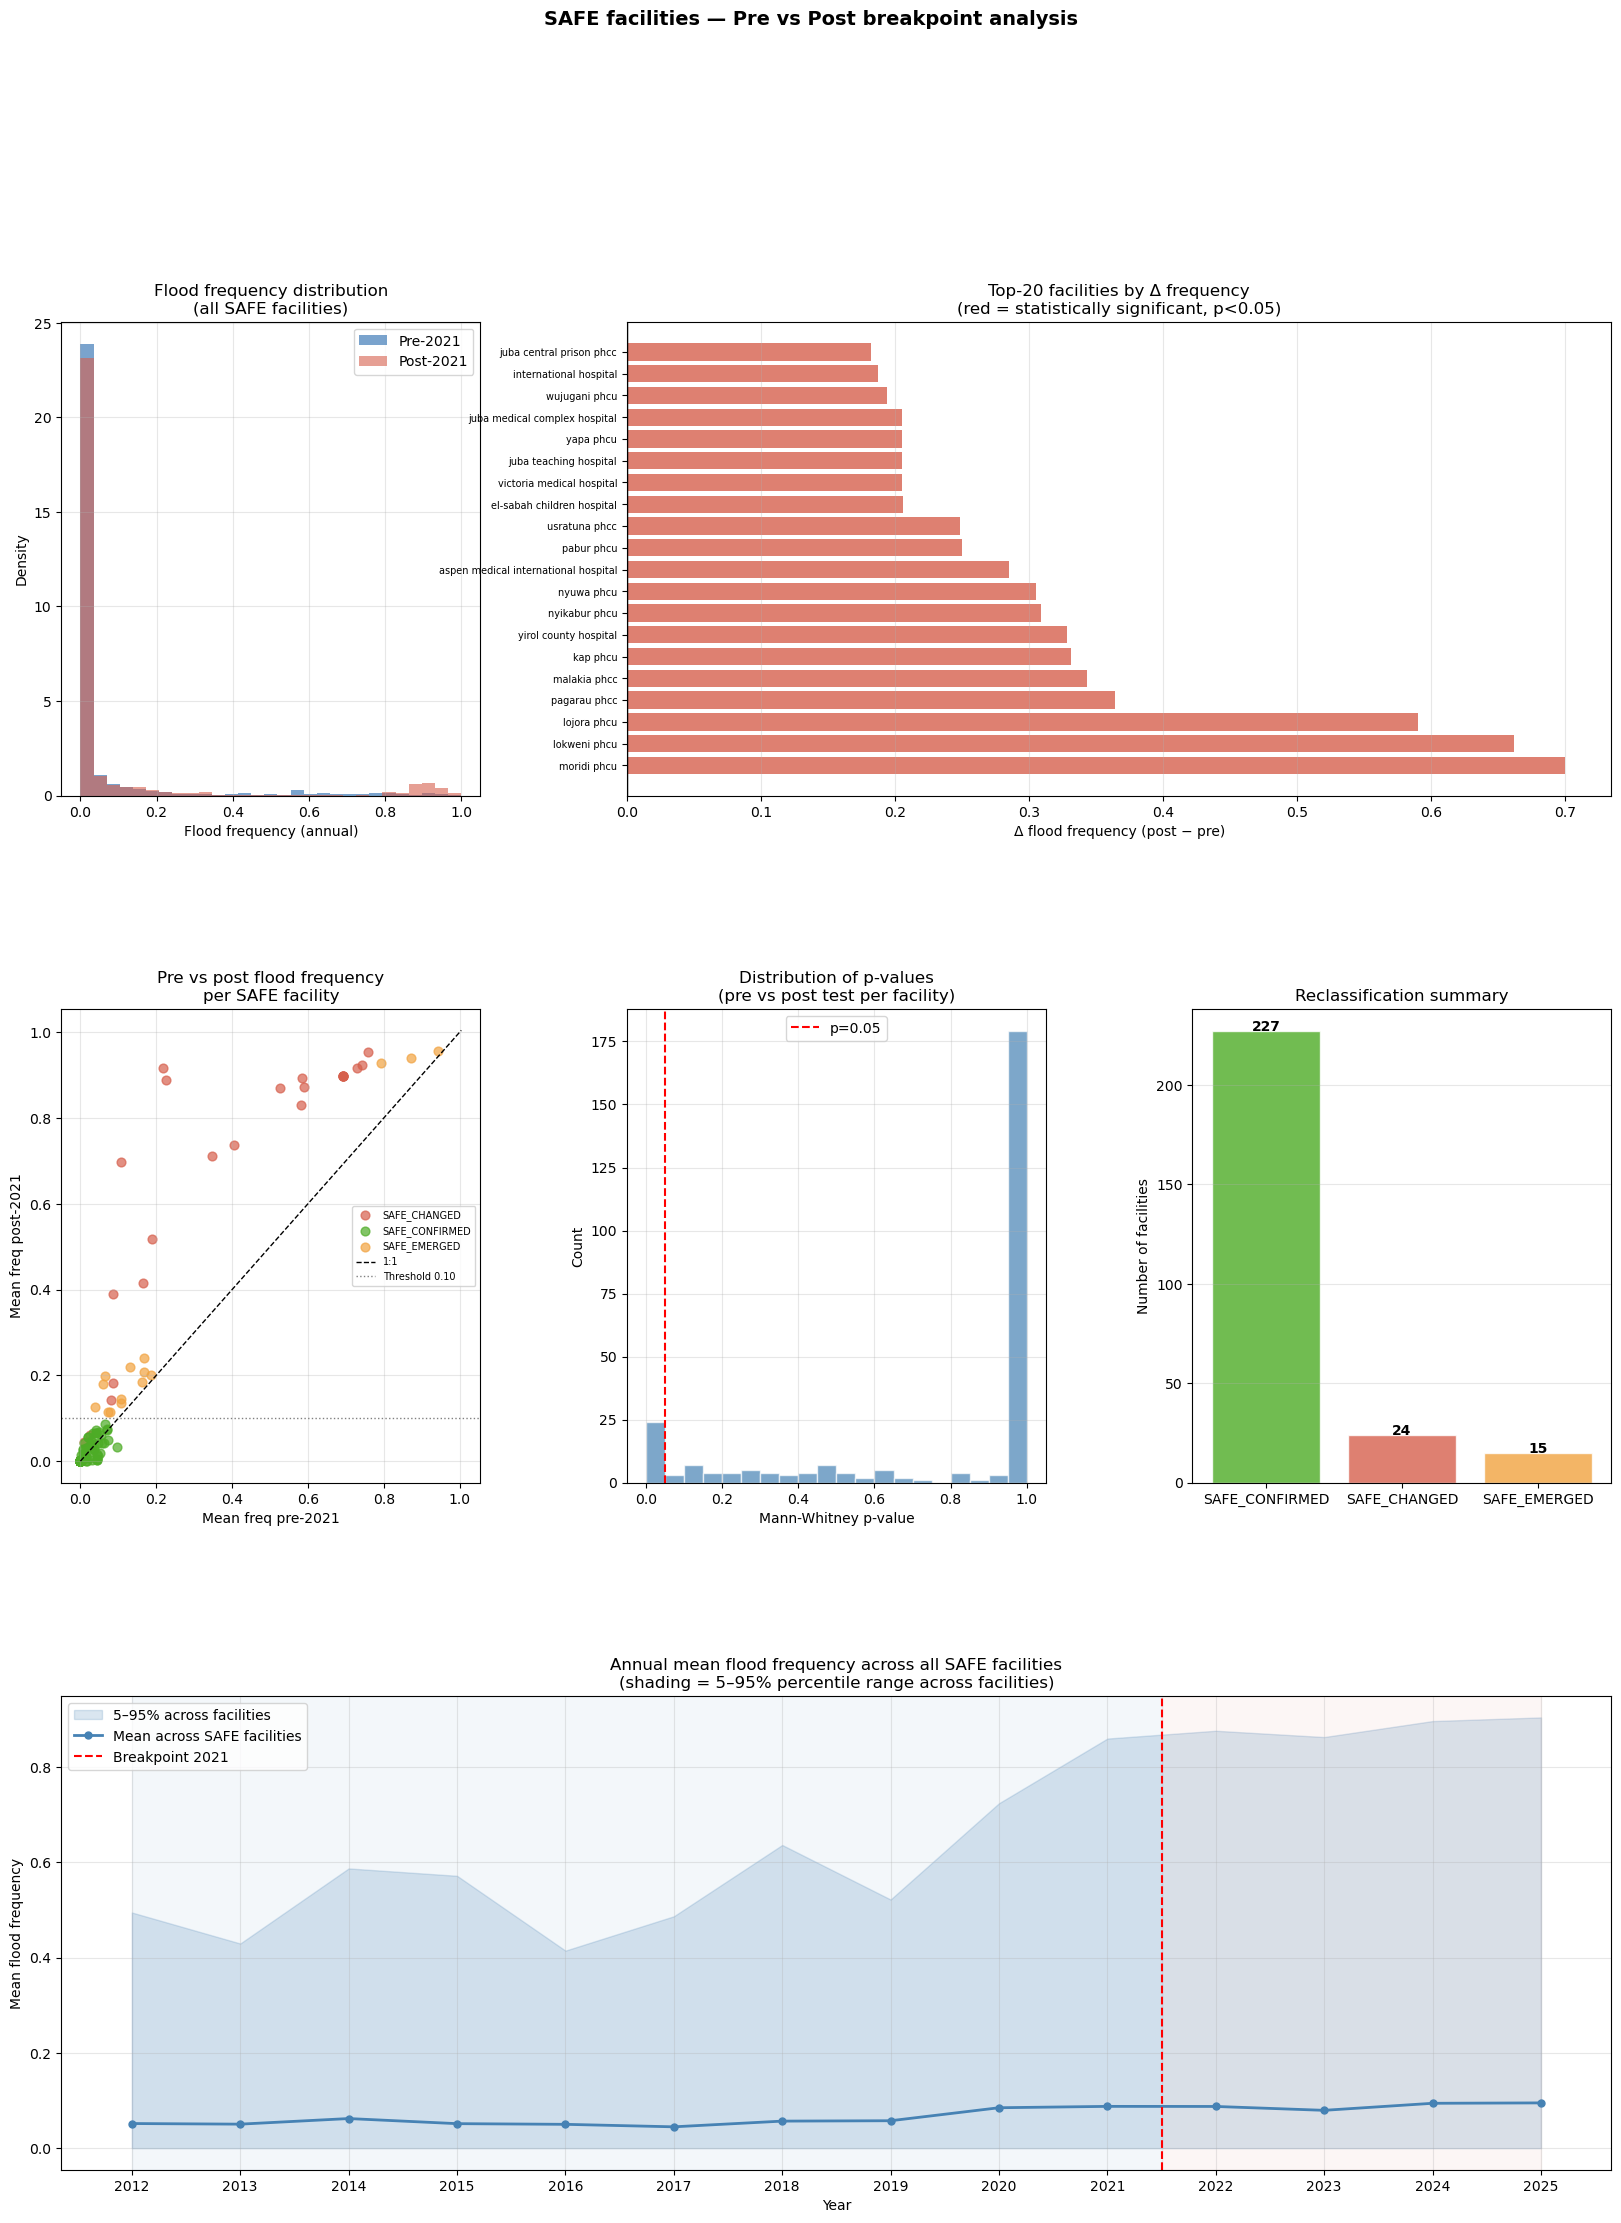

In [ ]:
print("Computing annual metrics...")
df_metrics = compute_annual_metrics(safe_fac)

print("Running pre/post statistical tests...")
df_tests = test_pre_post(df_metrics)
df_tests  = classify_safe_facilities(df_tests, freq_threshold=0.10)

print("Plotting...")
fig = plot_safe_analysis(df_metrics, df_tests, top_n_facilities=20)
plt.show()

In [ ]:
print_summary(df_tests)


SAFE FACILITIES — RECLASSIFICATION SUMMARY
  SAFE_CONFIRMED      :  227  (85.3%)
  SAFE_CHANGED        :   24  (9.0%)
  SAFE_EMERGED        :   15  (5.6%)

Facilities to RECLASSIFY (SAFE_CHANGED + SAFE_EMERGED):
                               hf_id  mean_pre  mean_post    delta     pval reclassification
                         moridi phcu  0.218210   0.917555 0.699345 0.001998     SAFE_CHANGED
                        lokweni phcu  0.226497   0.888401 0.661903 0.013986     SAFE_CHANGED
                         lojora phcu  0.106652   0.696697 0.590045 0.007388     SAFE_CHANGED
                        pagarau phcc  0.348228   0.712507 0.364279 0.023976     SAFE_CHANGED
                        malakia phcc  0.527146   0.870364 0.343218 0.000100     SAFE_CHANGED
                            kap phcu  0.404790   0.736112 0.331322 0.007992     SAFE_CHANGED
               yirol county hospital  0.189161   0.517536 0.328375 0.007992     SAFE_CHANGED
                       nyikabur phcu  0.585

#### Categories: UNSTABLE, CRITIC AND CHRONIC
***

In [ ]:
def classify_facility_change(df_tests, freq_threshold=0.10):
    """
    Generic version for any category.
    It classifies the type of pre/post change without assuming they are SAFE.
    """
    def classify(row):
        if row['significant'] and row['delta'] > freq_threshold:
            return 'INCREASED'        # significant increase
        elif row['significant'] and row['delta'] < -freq_threshold:
            return 'DECREASED'        # significant decrease
        elif not row['significant'] and row['mean_post'] < freq_threshold:
            return 'STABLE_LOW'       # no change, low frequency
        elif not row['significant']:
            return 'STABLE'           # no significant change
        else:
            return 'MARGINAL'         # small but significant change
    
    df_tests['reclassification'] = df_tests.apply(classify, axis=1)
    return df_tests

In [ ]:
# ==========================================================
# 4. VISUALIZATION (GENERIC, ANY CATEGORY)
# ==========================================================

def plot_cat_analysis(df_metrics, cat, df_tests, top_n_facilities=20):
    
    fig = plt.figure(figsize=(20, 24))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
    
    # ── Period palette ───────────────────────────────────────────────────
    CPRE  = '#2166ac'
    CPOST = '#d6604d'
    
    # ── 1. Flood frequency distribution pre vs post (all facilities) ─
    ax1 = fig.add_subplot(gs[0, 0])
    pre_all  = df_metrics[df_metrics['period'] == 'pre' ]['flood_freq']
    post_all = df_metrics[df_metrics['period'] == 'post']['flood_freq']
    bins = np.linspace(0, 1, 30)
    ax1.hist(pre_all,  bins=bins, alpha=0.6, color=CPRE,  label=f'Pre-{BREAKPOINT}',  density=True)
    ax1.hist(post_all, bins=bins, alpha=0.6, color=CPOST, label=f'Post-{BREAKPOINT}', density=True)
    ax1.set_xlabel('Flood frequency (annual)')
    ax1.set_ylabel('Density')
    ax1.set_title('Flood frequency distribution\n(all facilities)')
    ax1.legend(); ax1.grid(alpha=0.3)
    
    # ── 2. Delta (post - pre) per facility, ordered ─────────────────────
    ax2 = fig.add_subplot(gs[0, 1:])
    top = df_tests.head(top_n_facilities)
    colors = ['#d6604d' if s else '#92c5de' for s in top['significant']]
    ax2.barh(range(len(top)), top['delta'], color=colors, alpha=0.8)
    ax2.axvline(0, color='black', lw=1)
    ax2.set_yticks(range(len(top)))
    ax2.set_yticklabels(top['hf_id'], fontsize=7)
    ax2.set_xlabel('Δ flood frequency (post − pre)')
    ax2.set_title(f'Top-{top_n_facilities} facilities by Δ frequency\n'
                  f'(red = statistically significant, p<0.05)')
    ax2.grid(alpha=0.3, axis='x')
    
    # ── 3. Scatter mean_pre vs mean_post ─────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    cmap = {'STABLE': '#4dac26', 
            'INCREASED'  : '#f1a340', 
            'DECREASED'  : '#d6604d',
            'STABLE_LOW' : '#92c5de',
            'MARGINAL'  : '#f3d5f9'}
    for cls, grp in df_tests.groupby('reclassification'):
        ax3.scatter(grp['mean_pre'], grp['mean_post'], 
                    label=cls, color=cmap[cls], alpha=0.7, s=40)
    lim = max(df_tests['mean_pre'].max(), df_tests['mean_post'].max()) * 1.05
    ax3.plot([0, lim], [0, lim], 'k--', lw=1, label='1:1')
    ax3.axhline(0.10, color='gray', ls=':', lw=1, label='Threshold 0.10')
    ax3.set_xlabel(f'Mean freq pre-{BREAKPOINT}')
    ax3.set_ylabel(f'Mean freq post-{BREAKPOINT}')
    ax3.set_title(f'Pre vs post flood frequency\nper {cat} facility')
    ax3.legend(fontsize=7); ax3.grid(alpha=0.3)
    
    # ── 4. p-value distribution ───────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.hist(df_tests['pval'], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax4.axvline(0.05, color='red', lw=1.5, ls='--', label='p=0.05')
    ax4.set_xlabel('Mann-Whitney p-value')
    ax4.set_ylabel('Count')
    ax4.set_title(f'Distribution of p-values\n(pre vs post test per {cat} facility)')
    ax4.legend(); ax4.grid(alpha=0.3)
    
    # ── 5. Counting per reclassification ─────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 2])
    counts = df_tests['reclassification'].value_counts()
    bars   = ax5.bar(counts.index, counts.values, 
                     color=[cmap[c] for c in counts.index], alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Number of facilities')
    ax5.set_title('Reclassification summary')
    ax5.grid(alpha=0.3, axis='y')
    
    # ── 6. Time series: annual mean across all facilities ────────────────
    ax6 = fig.add_subplot(gs[2, :])
    annual_mean = (
        df_metrics.groupby('year')['flood_freq']
        .agg(['mean', 'std', lambda x: x.quantile(0.05), lambda x: x.quantile(0.95)])
    )
    annual_mean.columns = ['mean', 'std', 'q05', 'q95']
    
    years = annual_mean.index
    ax6.fill_between(years, annual_mean['q05'], annual_mean['q95'],
                     alpha=0.2, color='steelblue', label='5–95% across facilities')
    ax6.plot(years, annual_mean['mean'], color='steelblue', lw=2, marker='o',
             markersize=5, label=f'Mean across {cat} facilities')
    ax6.axvline(BREAKPOINT + 0.5, color='red', ls='--', lw=1.5,
                label=f'Breakpoint {BREAKPOINT}')
    
    # Color background pre/post
    ax6.axvspan(years.min(), BREAKPOINT + 0.5, alpha=0.05, color=CPRE)
    ax6.axvspan(BREAKPOINT + 0.5, years.max(), alpha=0.05, color=CPOST)
    
    ax6.set_xlabel('Year')
    ax6.set_ylabel('Mean flood frequency')
    ax6.set_title(f'Annual mean flood frequency across all {cat} facilities\n'
                  f'(shading = 5–95% percentile range across {cat} facilities)')
    ax6.legend(); ax6.grid(alpha=0.3)
    ax6.set_xticks(years)
    
    fig.suptitle(f'{cat} facilities — Pre vs Post breakpoint analysis',
                 fontsize=14, fontweight='bold', y=1.01)
    
    return fig

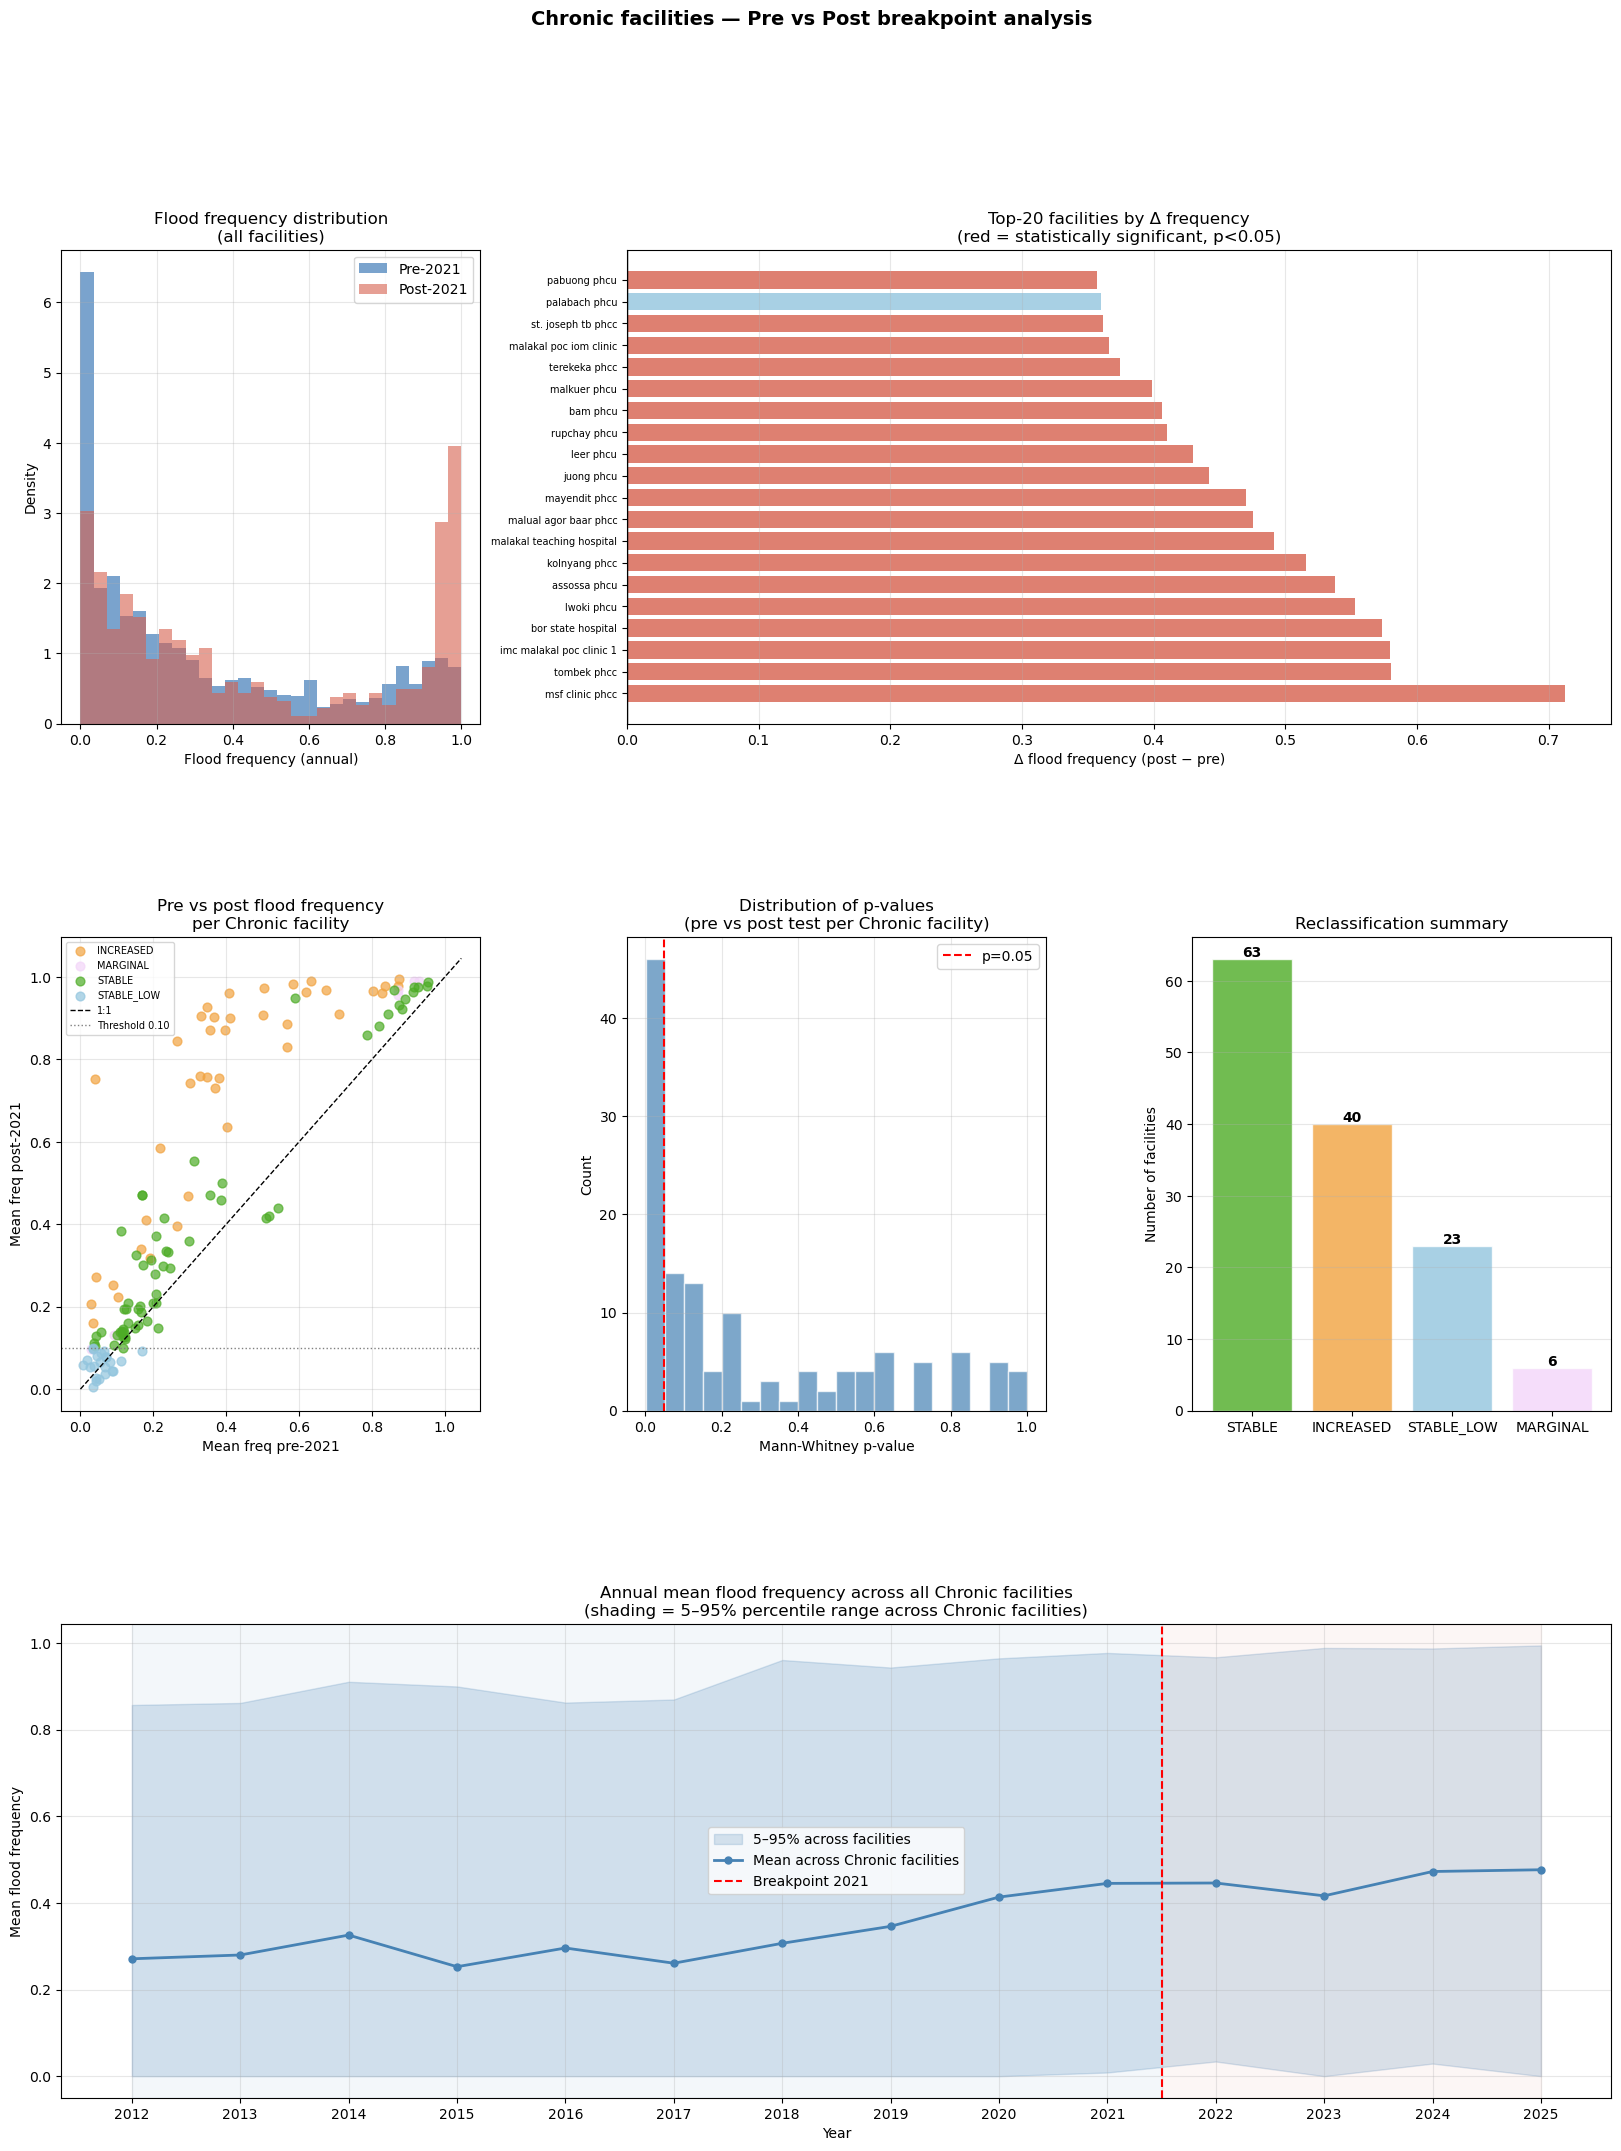

In [ ]:
df_chr = df_mod[df_mod["zona_name"] == "CHRONIC"].copy()
df_metrics_chr = compute_annual_metrics(df_chr)
df_tests_chr   = test_pre_post(df_metrics_chr)
df_tests_chr   = classify_facility_change(
    df_tests_chr, freq_threshold=0.10
)

fig = plot_cat_analysis(
    df_metrics_chr, "Chronic", df_tests_chr, top_n_facilities=20
)
fig.suptitle(
    f'Chronic facilities — Pre vs Post breakpoint analysis',
    fontsize=14, fontweight='bold'
)
plt.show()

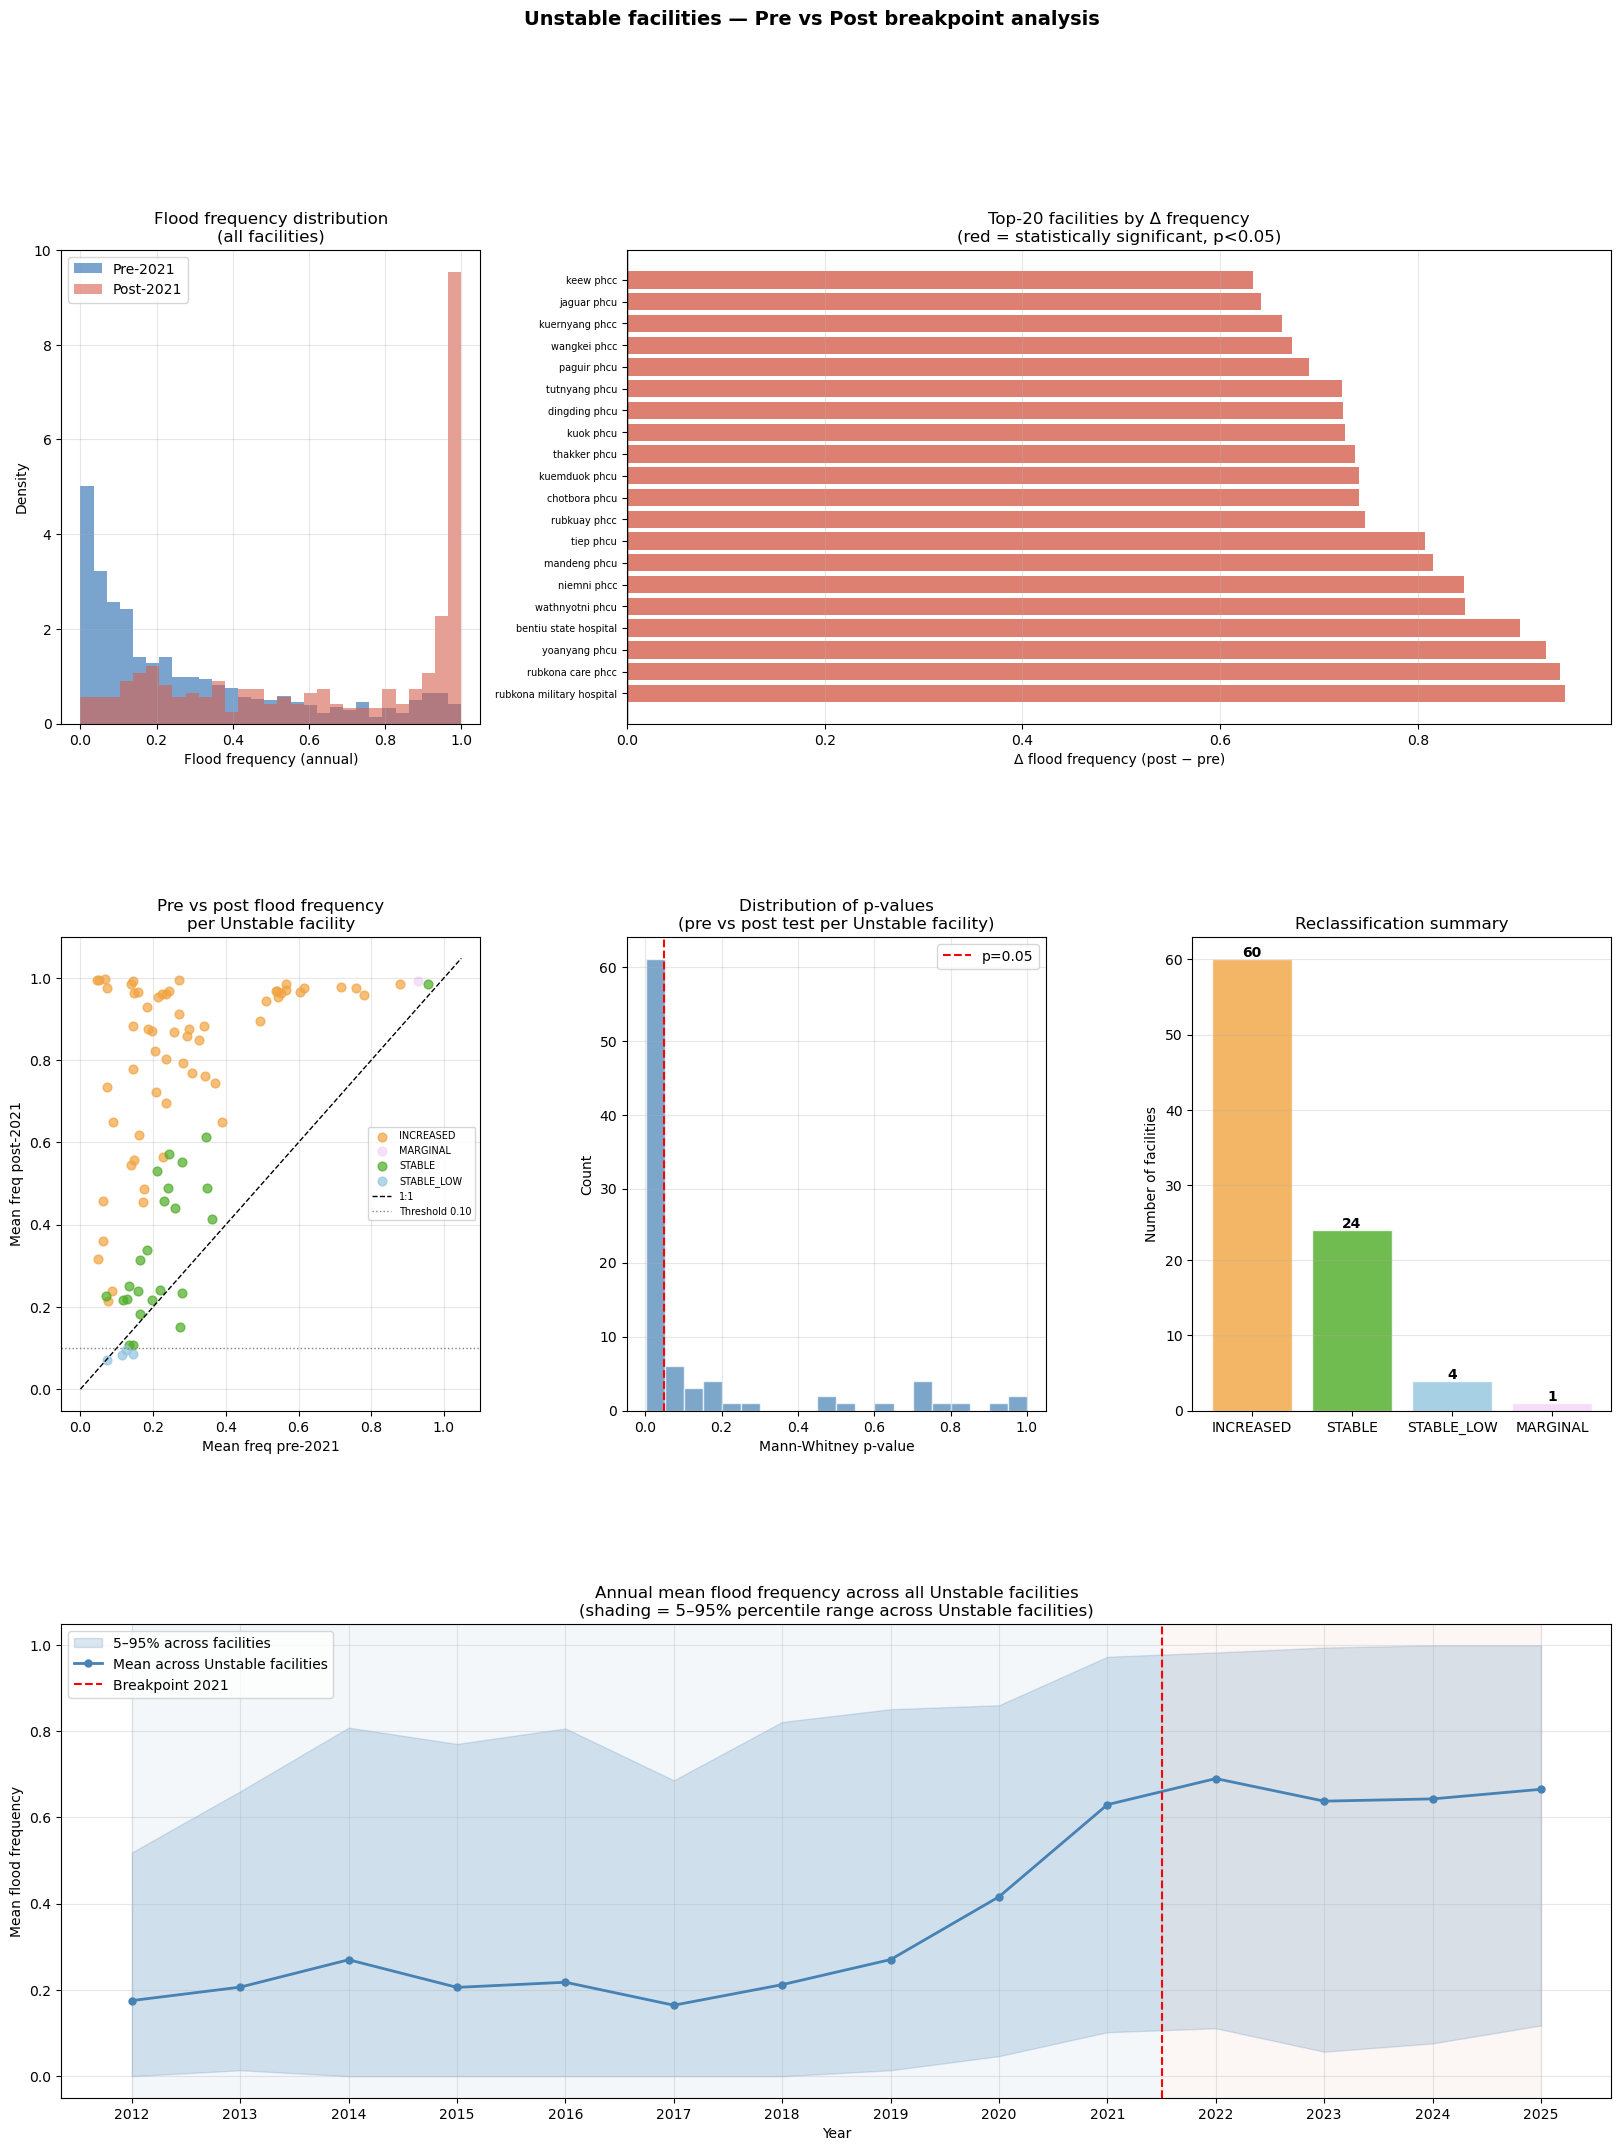

In [ ]:
df_uns = df_mod[df_mod["zona_name"] == "UNSTABLE"].copy()
df_metrics_uns = compute_annual_metrics(df_uns)
df_tests_uns   = test_pre_post(df_metrics_uns)
df_tests_uns   = classify_facility_change(
    df_tests_uns, freq_threshold=0.10
)

fig = plot_cat_analysis(
    df_metrics_uns, "Unstable", df_tests_uns, top_n_facilities=20
)
fig.suptitle(
    f'Unstable facilities — Pre vs Post breakpoint analysis',
    fontsize=14, fontweight='bold'
)
plt.show()

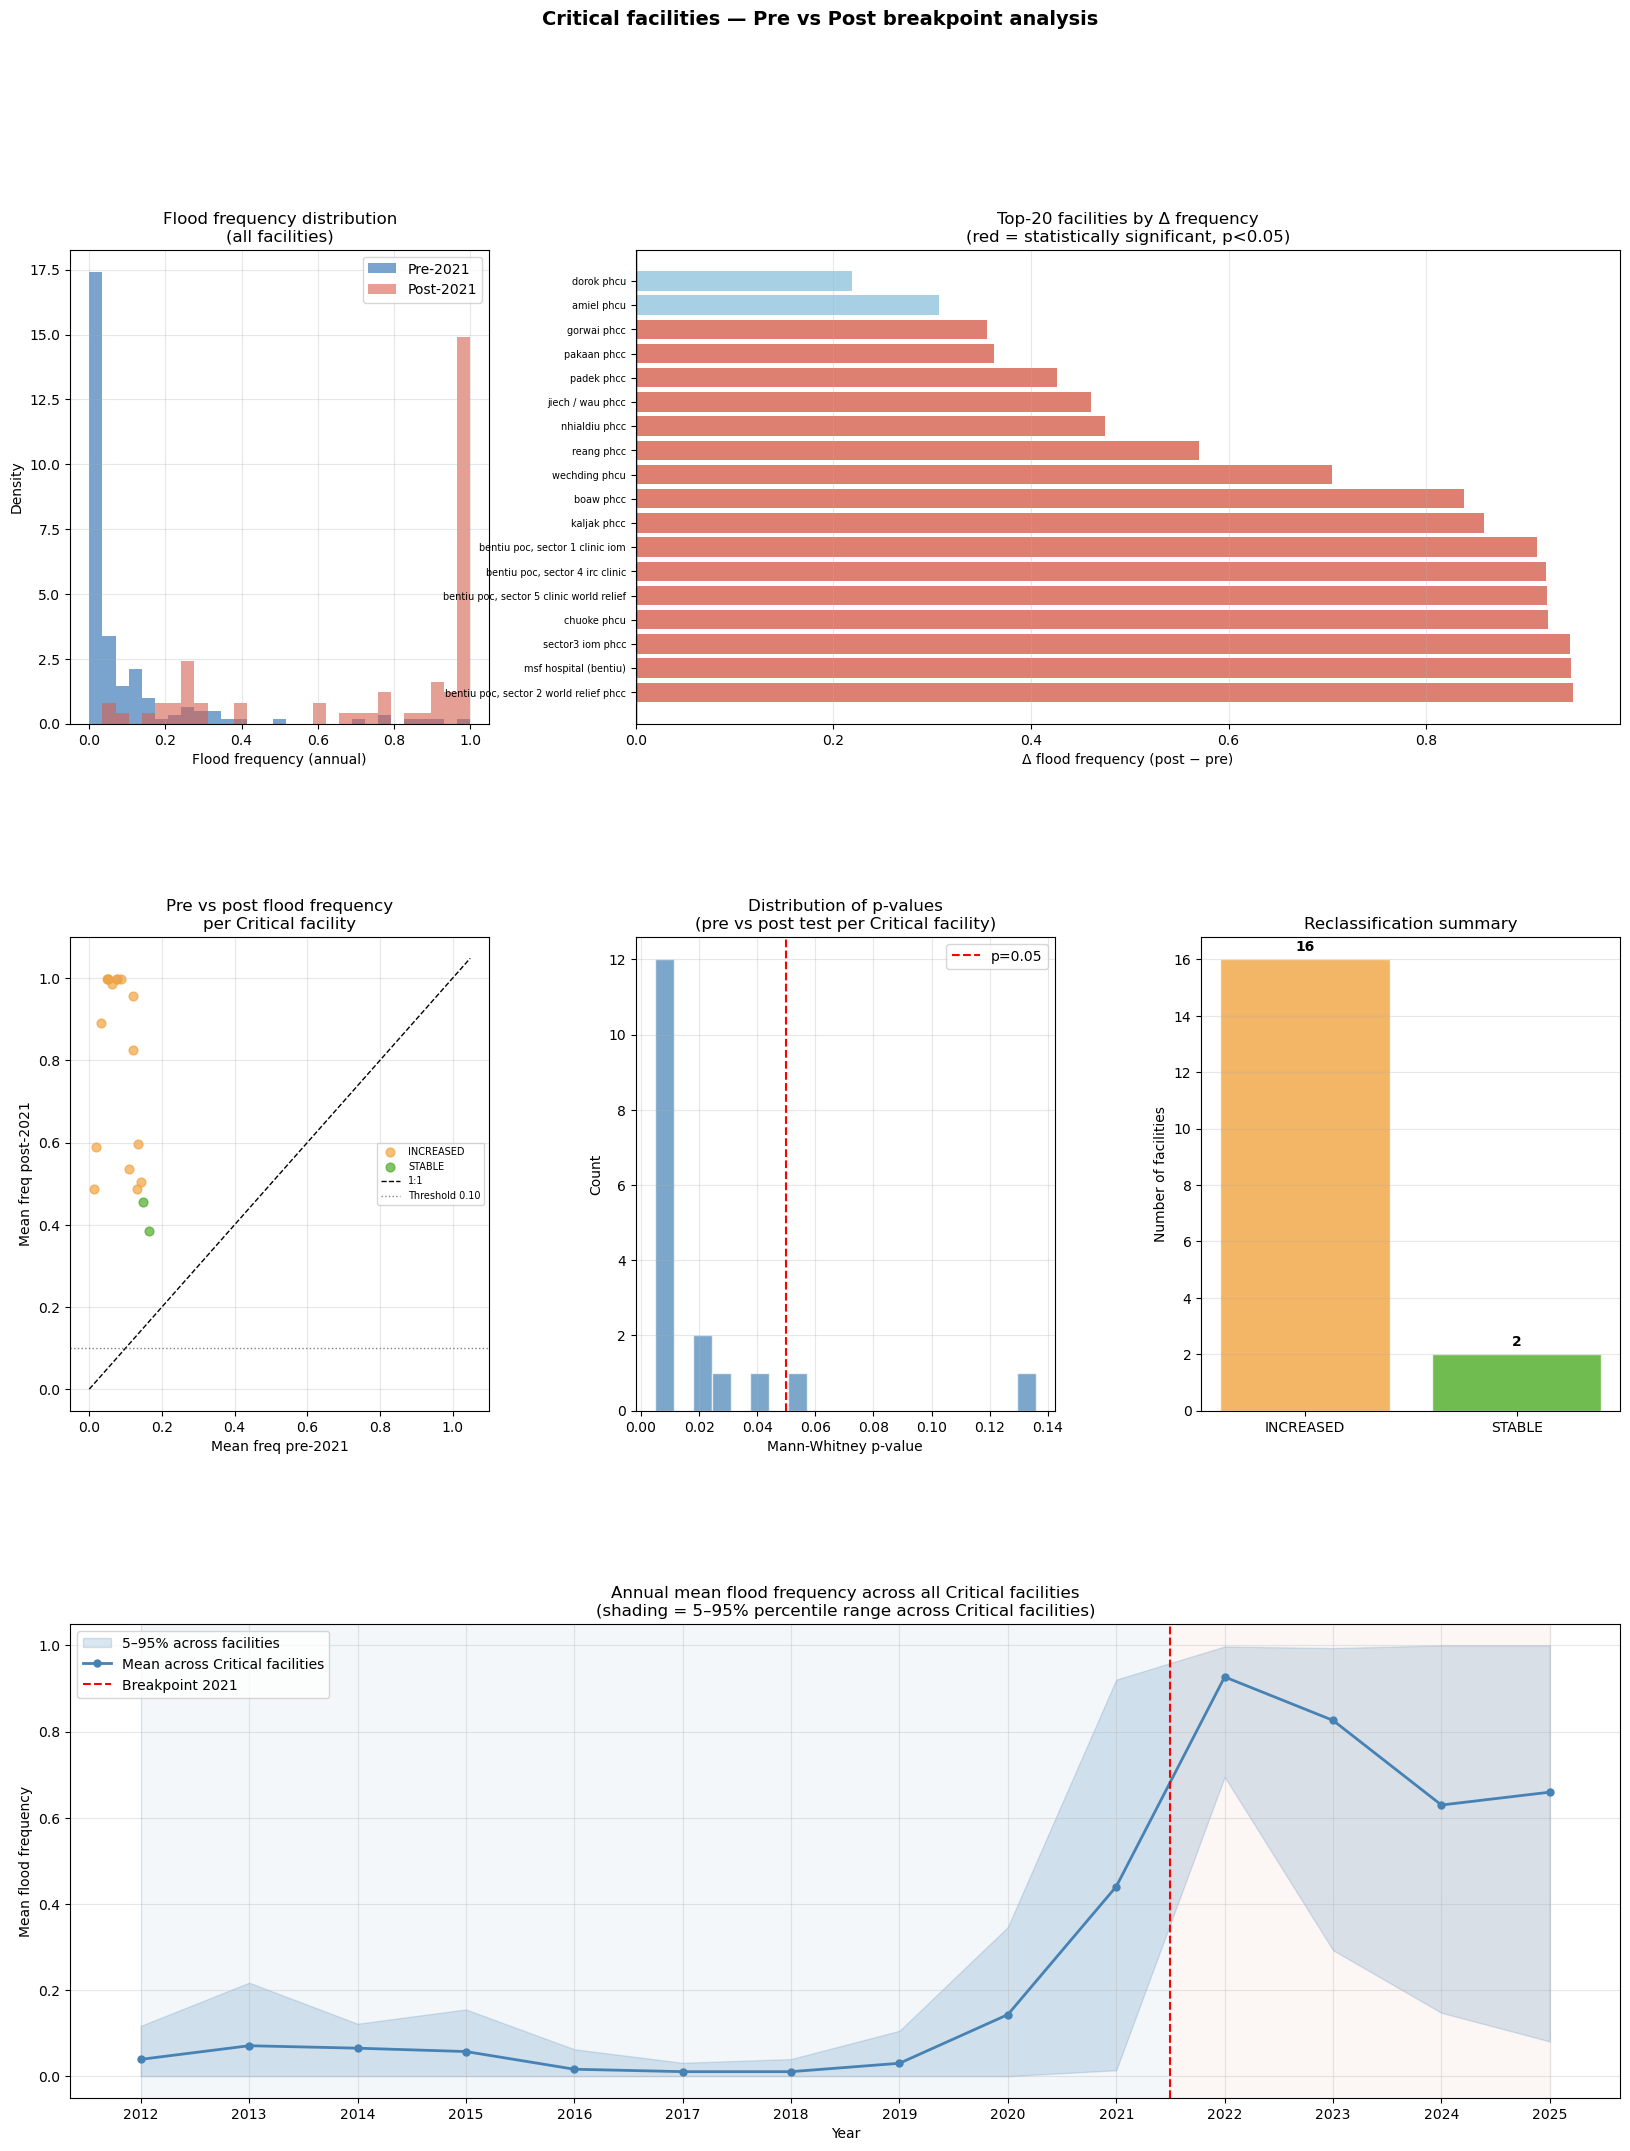

In [ ]:
df_cri = df_mod[df_mod["zona_name"] == "CRITICAL"].copy()
df_metrics_cri = compute_annual_metrics(df_cri)
df_tests_cri   = test_pre_post(df_metrics_cri)
df_tests_cri   = classify_facility_change(
    df_tests_cri, freq_threshold=0.10
)

fig = plot_cat_analysis(
    df_metrics_cri, "Critical", df_tests_cri, top_n_facilities=20
)
fig.suptitle(
    f'Critical facilities — Pre vs Post breakpoint analysis',
    fontsize=14, fontweight='bold'
)
plt.show()

In [38]:
df_tests_cri.head()

,hf_id,mean_pre,mean_post,delta,pval,significant,reclassification
2,"bentiu poc, sector 2 world relief phcc",0.048657,0.997730,0.949073,0.005244,True,INCREASED
11,msf hospital (bentiu),0.051293,0.997730,0.946437,0.005244,True,INCREASED
16,sector3 iom phcc,0.051648,0.997730,0.946082,0.005244,True,INCREASED
6,chuoke phcu,0.062371,0.985721,0.923350,0.005767,True,INCREASED
4,"bentiu poc, sector 5 clinic world relief",0.075771,0.997730,0.921959,0.005713,True,INCREASED


### Reclassification of selected facilitites
***

In [ ]:
def reclassify_facilities(df_tests_by_cat: dict, 
                           df_original: pd.DataFrame,
                           freq_threshold_high: float = 0.40,
                           freq_threshold_mid:  float = 0.10,
                           n_years_min:         int   = 3) -> pd.DataFrame:
    """This function performs the reclassification of facilities based on the 
    results of the pre/post analysis and the original category.
    
    Applies the reclassification rules by original category.
    
    df_tests_by_cat: dict with key = category, value = df_tests 
                     result of test_pre_post + classify
    df_original    : dataframe with original hf_id and hf_category (zona_name)
    
    Rules (example for SAFE, similar logic for others):
      SAFE_CHANGED  + mean_post > 0.40 → UNSTABLE
      SAFE_CHANGED  + mean_post 0.10-0.40 → CHRONIC
      SAFE_EMERGED  → CHRONIC
      CRITICAL      + mean_post > 0.50 → UNSTABLE
      CHRONIC/UNSTABLE → no change
      n_years_post < n_years_min → mark as UNCERTAIN, do not reclassify
    """
    
    # Build map hf_id → original category
    cat_map = (
        df_original[['hf_id', 'zona_name']]
        .drop_duplicates('hf_id')
        .set_index('hf_id')['zona_name']
        .to_dict()
    )
    
    reclassification_records = []
    
    for cat_original, df_tests in df_tests_by_cat.items():
        for _, row in df_tests.iterrows():
            fid        = row['hf_id']
            mean_post  = row['mean_post']
            n_years    = row.get('n_years_post', 99)
            change     = row.get('reclassification', row.get('change_type', ''))
            
            # By default: keep original category
            new_cat = cat_original
            reason  = 'no_change'
            
            # Insufficient post years: do not reclassify
            if n_years < n_years_min:
                new_cat = cat_original
                reason  = 'uncertain_few_years'
            
            elif cat_original == 'SAFE':
                if change == 'SAFE_CHANGED' and mean_post > freq_threshold_high:
                    new_cat = 'UNSTABLE'
                    reason  = 'safe_emerged_high'
                elif change == 'SAFE_CHANGED' and mean_post > freq_threshold_mid:
                    new_cat = 'CHRONIC'
                    reason  = 'safe_emerged_mid'
                elif change == 'SAFE_EMERGED':
                    new_cat = 'CHRONIC'
                    reason  = 'safe_emerged_low'
            
            elif cat_original == 'CRITICAL':
                if change == 'INCREASED' and mean_post > 0.50:
                    new_cat = 'UNSTABLE'
                    reason  = 'critical_now_persistent'
            
            # CHRONIC and UNSTABLE: no reclassification
            
            reclassification_records.append({
                'hf_id'          : fid,
                'cat_original'   : cat_original,
                'cat_new'        : new_cat,
                'mean_pre'       : row['mean_pre'],
                'mean_post'      : mean_post,
                'delta'          : row['delta'],
                'pval'           : row['pval'],
                'change_type'    : change,
                'n_years_post'   : n_years,
                'reclassified'   : new_cat != cat_original,
                'reason'         : reason,
            })
    
    df_reclass = pd.DataFrame(reclassification_records)
    
    # Summary
    print("\n" + "="*60)
    print("RECLASSIFICATION SUMMARY")
    print("="*60)
    changed = df_reclass[df_reclass['reclassified']]
    print(f"Total facilities  : {len(df_reclass)}")
    print(f"Reclassified      : {len(changed)} "
          f"({100*len(changed)/len(df_reclass):.1f}%)")
    print("\nMovements:")
    movements = (
        changed.groupby(['cat_original', 'cat_new'])
        .size()
        .reset_index(name='count')
    )
    for _, m in movements.iterrows():
        print(f"  {m['cat_original']:<12} → {m['cat_new']:<12} : {m['count']}")
    
    uncertain = df_reclass[df_reclass['reason'] == 'uncertain_few_years']
    if len(uncertain):
        print(f"\nMarked UNCERTAIN (< {n_years_min} post years): {len(uncertain)}")
    
    return df_reclass


# ── Use ──────────────────────────────────────────────────────────────────────

# Step 1: execute analysis pre/post per category
df_tests_by_cat = {}
for cat in ['SAFE', 'CHRONIC', 'UNSTABLE', 'CRITICAL']:
    df_cat     = df_mod[df_mod['zona_name'] == cat].copy()
    df_metrics = compute_annual_metrics(df_cat)
    df_tests   = test_pre_post(df_metrics)
    
    if cat == 'SAFE':
        df_tests = classify_safe_facilities(df_tests, freq_threshold=0.10)
    else:
        df_tests = classify_facility_change(df_tests, freq_threshold=0.10)
    
    # Add n_years_post
    years_post = (
        df_cat[df_cat['year'] > 2021]
        .groupby('hf_id')['year'].count()
        .reset_index()
        .rename(columns={'year': 'n_years_post'})
    )
    df_tests = df_tests.merge(years_post, on='hf_id', how='left')
    df_tests['n_years_post'] = df_tests['n_years_post'].fillna(0).astype(int)
    
    df_tests_by_cat[cat] = df_tests

# Step 2: reclassify
df_reclass = reclassify_facilities(
    df_tests_by_cat = df_tests_by_cat,
    df_original     = df_mod,          
    freq_threshold_high = 0.40,
    freq_threshold_mid  = 0.10,
    n_years_min         = 3,
)

# Step 3: apply to the model input dataframe
hf_cat_new = df_reclass.set_index('hf_id')['cat_new'].to_dict()


RECLASSIFICATION SUMMARY
Total facilities  : 505
Reclassified      : 51 (10.1%)

Movements:
  CRITICAL     → UNSTABLE     : 14
  SAFE         → CHRONIC      : 18
  SAFE         → UNSTABLE     : 19


In [ ]:

df_reclass.head(3)

,hf_id,cat_original,cat_new,mean_pre,mean_post,delta,pval,change_type,n_years_post,reclassified,reason
0,moridi phcu,SAFE,UNSTABLE,0.218210,0.917555,0.699345,0.001998,SAFE_CHANGED,4,True,safe_emerged_high
1,lokweni phcu,SAFE,UNSTABLE,0.226497,0.888401,0.661903,0.013986,SAFE_CHANGED,4,True,safe_emerged_high
2,lojora phcu,SAFE,UNSTABLE,0.106652,0.696697,0.590045,0.007388,SAFE_CHANGED,4,True,safe_emerged_high


In [18]:
df_final = df.merge(df_reclass[['hf_id', 'cat_new', 'cat_original', 'reclassified','reason']], on='hf_id', how='inner')

In [46]:
df_final.head(4)

,hf_county,hf_payam,hf_id,hf_type,latitude,longitude,year,n_days,buffer_pixels,buffer_meters,...,dates,series_binary,series_pct_flood_pixels,series_distance_m,series_no_data_count,total_flooded_days,cat_new,cat_original,reclassified,reason
0,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2012,337,40,3600.0,...,"[2012-01-24 00:00:00, 2012-01-25 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,CHRONIC,CHRONIC,False,no_change
1,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2013,363,40,3600.0,...,"[2013-01-01 00:00:00, 2013-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",45,CHRONIC,CHRONIC,False,no_change
2,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2014,365,40,3600.0,...,"[2014-01-01 00:00:00, 2014-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",15,CHRONIC,CHRONIC,False,no_change
3,SS0601,SS060101,abiemnom phcc,PHCC,9.39874,28.8234,2015,365,40,3600.0,...,"[2015-01-01 00:00:00, 2015-01-02 00:00:00, 201...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[None, None, None, None, None, None, None, Non...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,CHRONIC,CHRONIC,False,no_change


In [ ]:
# Serialize lists to JSON strings for CSV export
df_save = df_final.copy()
for col in ['series_binary', 'series_pct_flood_pixels', 'series_distance_m']:
    df_save[col] = df_save[col].apply(json.dumps)
df_save['dates'] = df_save['dates'].apply(
    lambda x: json.dumps([d.strftime('%Y-%m-%d') for d in x])
)
df_save.to_csv(
    "../data/eo_pool/eo_pool_reclassified.csv",
    index=False
)
print(f"Saved: {len(df_save)} facilities with reclassified categories")

Guardado: 7126 facilities con categorías reclasificadas
